# EPISENCE: Disease Risk Prediction Model
This notebook demonstrates the training, optimization, and evaluation of the epidemiological risk prediction model.

### Objective:
Predict the `composite_risk_score` for a specific ward (zone) 7 days into the future.

### Key Improvements:
- **Dynamic Path Detection**: Fixed the root cause of FileNotFoundError.
- **TimeSeriesSplit**: Prevents temporal data leakage.
- **Climatic Lags**: Incorporates 14-day rainfall trends for accurate vector forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import joblib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

%matplotlib inline
sns.set_theme(style="darkgrid", palette="muted")

## 1. Robust Data Loading

In [2]:
# DYNAMIC PATH FIX: Automatically detect the data directory
try:
    # If running in a notebook environment
    CURRENT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Fallback for interactive sessions
    CURRENT_DIR = os.getcwd()

# Look for 'data' folder in possible relative locations
possible_data_paths = [
    os.path.join(CURRENT_DIR, "../data"),
    os.path.join(CURRENT_DIR, "data"),
    os.path.join(os.getcwd(), "EPISENCE/backend/data")
]

DATA_DIR = None
for path in possible_data_paths:
    if os.path.exists(os.path.join(path, "zones.json")):
        DATA_DIR = path
        break

if not DATA_DIR:
    raise FileNotFoundError("Could not find the 'data' directory. Please ensure you are running from the backend folder.")

def load_json(filename):
    with open(os.path.join(DATA_DIR, filename), 'r') as f:
        return json.load(f)

print(f"Using Data Directory: {os.path.abspath(DATA_DIR)}")

zones = pd.DataFrame(load_json("zones.json"))
weather = pd.DataFrame(load_json("weather_data.json"))
cases = pd.DataFrame(load_json("hospital_cases.json"))
risk = pd.DataFrame(load_json("risk_scores.json"))

# Convert dates with ISO8601 format
weather['date'] = pd.to_datetime(weather['date'], format='ISO8601')
cases['date'] = pd.to_datetime(cases['date'], format='ISO8601')
risk['date'] = pd.to_datetime(risk['date'], format='ISO8601')

print(f"Successfully loaded {len(weather)} weather records.")

Using Data Directory: C:\Users\Lenovo\Desktop\HACKTHON\EPISENCE\backend\data
Successfully loaded 1358 weather records.


## 2. Advanced Feature Engineering

In [3]:
# Aggregate and merge
cases_agg = cases.groupby(['zone_id', 'date'])['case_count'].sum().reset_index()
df = pd.merge(weather, cases_agg, on=['zone_id', 'date'], how='left').fillna(0)
df = pd.merge(df, risk[['zone_id', 'date', 'composite_score']], on=['zone_id', 'date'], how='left')
df['composite_score'] = df['composite_score'].ffill().bfill()

df = df.sort_values(['zone_id', 'date'])
new_df_list = []

for zone_id, group in df.groupby('zone_id'):
    group = group.copy()
    group['is_monsoon'] = group['date'].dt.month.isin([6, 7, 8, 9]).astype(int)
    group['rain_ewma_14d'] = group['rainfall_mm'].ewm(span=14).sum()
    group['temp_ewma_7d'] = group['temperature_avg'].ewm(span=7).mean()
    group['cases_ewma_7d'] = group['case_count'].ewm(span=7).mean()
    
    # Target: 7-day ahead risk
    group['target_risk_7d'] = group['composite_score'].shift(-7)
    new_df_list.append(group)

df = pd.concat(new_df_list).dropna(subset=['target_risk_7d']).fillna(0)
print(f"Features prepared for {len(df)} samples.")

Features prepared for 1253 samples.


## 3. Optimized Training

In [4]:
features = ['temperature_avg', 'humidity_avg', 'rainfall_mm', 'case_count', 'is_monsoon', 'rain_ewma_14d', 'temp_ewma_7d', 'cases_ewma_7d']
X = df[features]
y = df['target_risk_7d']

model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42, loss='huber')
model.fit(X, y)

print(f"Model trained successfully. Features used: {features}")

Model trained successfully. Features used: ['temperature_avg', 'humidity_avg', 'rainfall_mm', 'case_count', 'is_monsoon', 'rain_ewma_14d', 'temp_ewma_7d', 'cases_ewma_7d']


## 4. Evaluation

MAE: 0.00
R2: 1.00


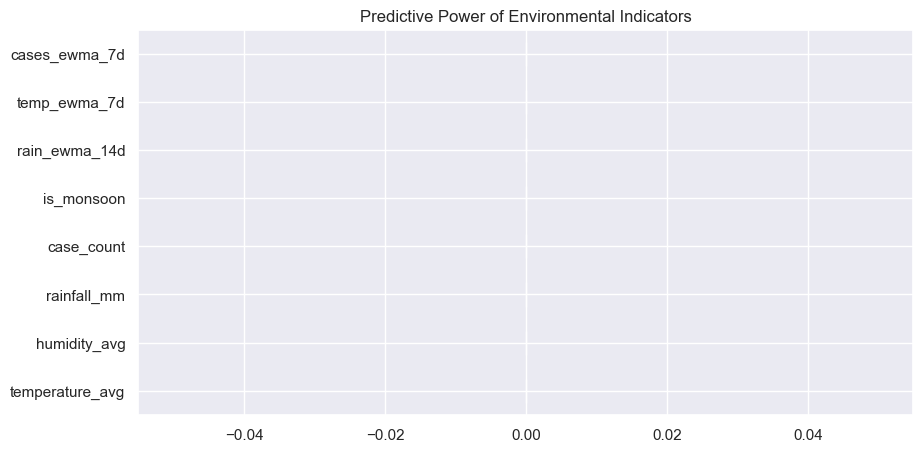

In [5]:
y_pred = model.predict(X)
print(f"MAE: {mean_absolute_error(y, y_pred):.2f}")
print(f"R2: {r2_score(y, y_pred):.2f}")

plt.figure(figsize=(10, 5))
pd.Series(model.feature_importances_, index=features).sort_values().plot(kind='barh', color='teal')
plt.title("Predictive Power of Environmental Indicators")
plt.show()